
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [ ]:
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv')
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520




1. Оцінити значення виходячи зі значень одної іншої змінної, яка найбільше корелює з цільовою, наприклад `charges` = деякий підібраний коефіцієнт, домножений на `age` (бо ця змінна, як побачили далі, значно корелює з цільовою)
2. Самостійно знайти правила для значення `charges` виходячи з кількох змінних, наприклад,
3. Розбити `bmi` на три групи: до 30 персентиля, з 30 по 70, з 70 по 100 персентилі. І для кожної групи вивести середнє значення `charges` - це і буде передбаченням. Хоча і не дуже точним :) Можна ще взяти одну змінну, наприклад `bmi` яку розбити на категорії і рахувати передбачення charges виходячи з неї та як фінальну оцінку виводити середнє значення передбачення по `age` і по `bmi`.

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [ ]:
# імпорти бібліотек для візуалізації
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline


In [ ]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   title='Annual Medical Charges by gender')
fig.update_layout(bargap=0.1)
fig.show()

1. **Розподіл витрат**: На гістограмі ми бачимо, що витрати зосереджені у двох основних діапазонах: менш як $10,000 та між $20,000 та $30,000. Ці витрати можуть відображати різні рівні медичного покриття або відмінності у стані здоров'я.

2. **Вплив статі**: З гістограм помітно, що чоловіки частіше знаходяться у вищих діапазонах витрат ($20k і більше), порівняно з жінками. Натомість, жінки частіше (суттєво, відсотків на 30) мають розмір зборів в діапазоні від $2k до $4k.

3. **Боксплоти (верхня частина графіку)**: Червоний боксплот (чоловіки) показує більш високий  рівень витрат 75го персентиля, а також більшу кількість викидів у вищому діапазоні витрат порівняно з синім (жінки), що також свідчить про вищі середні витрати серед чоловіків.

4. **Викиди**: На обох боксплотах присутні викиди (точки поза 'вусами'), що вказує на наявність осіб із значно вищими витратами на медичне страхування, ніж переважна більшість. Це можуть бути люди з серйозними медичними умовами або ті, хто отримав інтенсивне лікування.

In [ ]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   title='Annual Medical Charges by region')
fig.update_layout(bargap=0.1)
fig.show()

1. **Загальна кількість зборів**: Гістограма показує, що у південно-східному (`southeast`) регіоні є найвища кількість клієнтів із вищими витратами, порівняно з іншими регіонами. Наприклад, більше клієнтів із цього регіону мають витрати більше 36k доларів, а також найбільша кількість клієнтів цього регіну мають витрати в діапазонах 18-20k і 26-28k.

2. **Боксплоти (верхня частина графіку)**: Вони показують, що південний схід (`southeast`) має більший розкид у витратах, включаючи найвище максимальне значення, що може свідчити про вищі витрати на медичне страхування в цьому регіоні. При цьому медіана витрат найвища в `northeast`.

3. **Викиди**: На боксплотах для всіх регіонів є викиди, які показують наявність клієнтів з особливо високими витратами на медичне страхування. Найдальше від основних значень викиди - в південно-східному регіоні (`southeast`).


**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [ ]:
px.histogram(medical_df, x='smoker', color='region', title='Smoker by region')

Виглядає, що відносно інших регіонів курців і `southeast` більше, ніж в решті.

In [ ]:
px.histogram(medical_df, x='smoker', color='children', title='Smoker by n of children')

Серед некурців більше людей, у яких немає дітей, 1 або 2 дитини. Серед курців немає людей, в кого 5 дітей.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [ ]:
fig = px.violin(medical_df,
                 y='charges',
                 color='children',
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [ ]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [ ]:
def estimate_charges(age, w, b):
    return w * age + b

In [ ]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

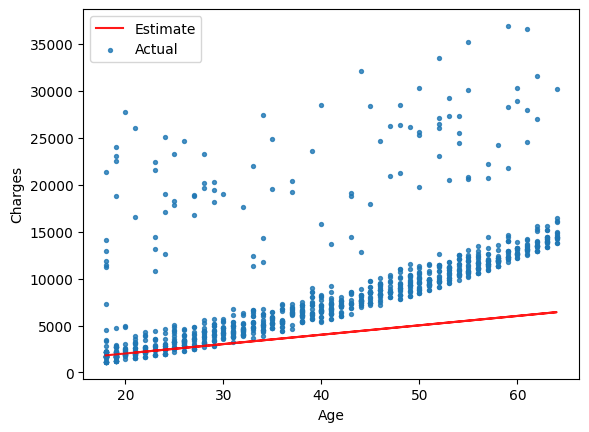

In [ ]:
try_parameters(non_smoker_df, 100, 20)

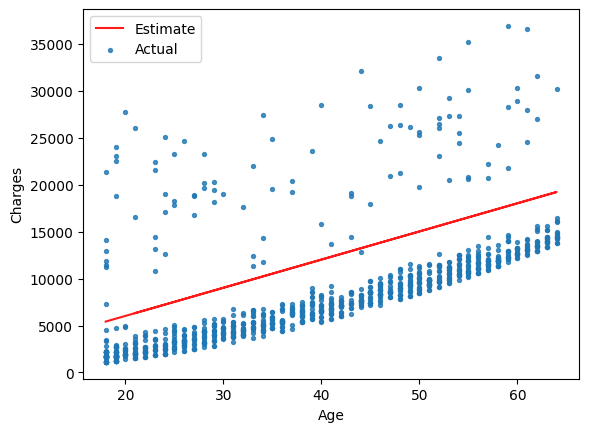

In [ ]:
try_parameters(non_smoker_df, 300, 20)

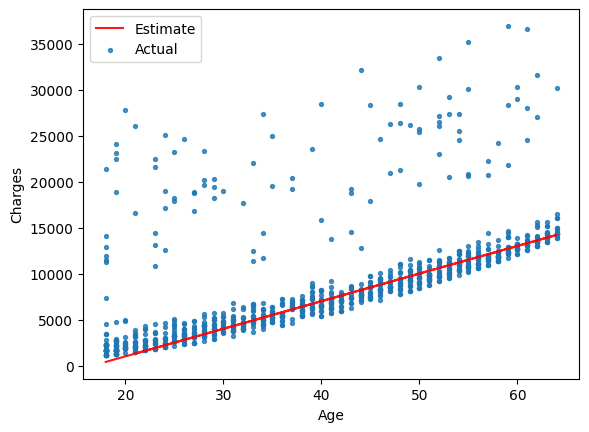

In [ ]:
try_parameters(non_smoker_df, 300, -5000)

Цими екпериментами в цілому виходить дібрати пряму, яка непогано буде узагальнювати тенденцію даних, але хочеться ще кількісно оцінити результат.

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [ ]:
import numpy as np

def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [ ]:
ages = non_smoker_df.age
target = non_smoker_df.charges

parameters = [(100, 20),(300,20),(280,-300)]
for pair in parameters:
  w, b = pair
  estimated_charges = estimate_charges(ages, w, b)
  rmse_ = rmse(target, estimated_charges)
  print(f'Для параметрів w={w} та b={b} RMSE={round(rmse_, 2)}')

Для параметрів w=100 та b=20 RMSE=6878.52
Для параметрів w=300 та b=20 RMSE=5789.7
Для параметрів w=280 та b=-300 RMSE=5199.22


Стратегія була - спочатку знайти оптимальний нахил, а потім знайти зміщення. В мене вийшло це зробити за біля 5 ітерацій.